## Notebook 6: When Accurate Models Produce Wrong Science: Bias and Uncertainty in Astronomical ML

 **Audience:** First-year PhD students in Astrophysics  
 **Theme:** Why models that look good can still produce bad science

---

### Astrophysics context

In modern surveys such as SDSS, DES, Euclid, Rubin/LSST, and Roman, machine learning is routinely used to estimate physical quantities:

- photometric redshift
- stellar parameters
- morphology
- transient class labels

However, many failures in scientific ML do **not** happen because the algorithm is weak.

They happen because:

- training labels are biased
- data distributions shift
- uncertainty is ignored
- hidden variables are missing
- models are used outside their domain of validity

---

### Scientific goal

Understand:

- selection bias
- distribution shift
- interpolation vs extrapolation
- overconfidence
- why uncertainty matters for science

---

### Core message

> A good model trained on bad data is still a bad model.

In astronomy, data limitations often dominate model choice.


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from matplotlib.colors import LinearSegmentedColormap
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_absolute_error, r2_score


## Set Random Seed and Plotting Style

This step initializes reproducibility and configures the default visualization settings.

A fixed random seed is defined to ensure that any random processes (such as sampling or model initialization) produce consistent results across runs. A NumPy random generator is created using this seed.

The plotting style is also set to a predefined Matplotlib theme that improves readability and accessibility. Default figure size and font size are adjusted to make all plots clearer and more consistent throughout the notebook.

These settings ensure that results are both reproducible and visually consistent across all visualizations.

In [2]:
SEED = 42
np.random.seed(SEED)

plt.style.use("tableau-colorblind10")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12


## 1. Scientific Context: Photometric Redshifts as an Inverse Problem

Modern surveys (SDSS, DES, LSST, Euclid, Roman) infer physical quantities from photometry:

* redshift
* stellar properties
* morphology
* transient classification

These problems are **inverse problems under incomplete and noisy observations**.

###### Compression, Information Loss and Degeneracy

A galaxy’s spectrum contains thousands of data points (lines, breaks, slopes). 

A telescope like LSST takes that rich spectrum and squashes it into broad filters ($u$,$g$,$r$,$i$).

We are projecting a high-dimensional physical space into a low-dimensional observational space.

When you squash data, you create Degeneracy (different physical states looking identical).

###### Forward Problem

If I have a galaxy with redshift $z$, age $T$, and dust $A_v$, what specific colors will my telescope see? 

(This is governed by electromagnetism and relativity).

###### Inverse Problem

I have four numbers (magnitudes $u$,$g$,$r$,$i$). 

What were the redshift $z$, age $T$, and dust $A_v$ that produced them?
  

To answer this question, we study photometric redshift estimation:

$
z \rightarrow \text{color} \rightarrow \hat{z}
$

where $\hat{z}$ denotes that it is an estimate and:
- $z \rightarrow \text{color}$ is the Physics (the Redshift-Color relation)
- $\text{color} \rightarrow \hat{z}$ is the ML Model (the inference). 

The goal of the notebook is to show that $\hat{z}$ is only as good as the information preserved in the $\text{color}$ intermediate step.
  
###### Summary

We consider an **Inverse Problem** where we aren't just fitting a line to points. 

We are trying to reconstruct the state of the universe from a handful of blurry, noisy pixels. 

If the pixels don't contain the information, the model can't invent it—it can only guess, and those guesses are where scientific bias begins.

The key difficulty are:

* observations are compressed projections of physical reality
* multiple physical states can map to similar observables

Even in simplified form:

* nonlinear mapping
* noise-induced overlap
* partial non-identifiability

> The inverse problem is weakly identifiable under limited observables.


## Unified View of the Problem

All experiments in this notebook can be expressed through: $p(z \mid x_{\text{photo}}, \mathcal{D}_{\text{train}})$

Notice that we use this as a conceptual representation, not a literal posterior.

###### 1. Observation model

This term represents the Forward Model.

$
x_{\text{photo}} = g(z, \epsilon)
$


- $g$ is the instrument (the telescope filters).

- $\epsilon$ is the universe's noise (stochasticity).

The ML is trying to "invert" the telescope's hardware. 

If $g$ is a "lossy" function (which it is), the inverse will always be ambiguous.

This encodes:

- nonlinear projection of physics into observables  
- measurement noise  
- information loss  

###### 2. Training distribution

$
\mathcal{D}_{\text{train}} \sim p_{\text{selected}}(x, z)
$

In statistics, the support is the set of values for which the probability is non-zero.

- Model fails when input features fall outside the training support, which often corresponds to high redshift.
  - This explains why the Random Forest we will train "flattens out" (it is physically incapable of imagining a universe outside its training support)

This encodes:

- selection bias  
- truncated redshift range  
- survey limitations  

###### Key Insight

The model does not learn: $p(z \mid x)$ but instead: $p(z \mid x, \text{biased support})$

Machine learning in astronomy is not pure function approximation.

In computer science, ML is often treated as finding a function $f(x)\approx y$.

In astronomy, we aren't just looking for $f(x)$. 
We are looking for physical truth in a sample that is fundamentally unrepresentative of the whole.

In cosmological terms, our training set is the Local Universe, but our science goals are at the Cosmic Horizon and thus:


> ML in astronomy is inference under biased, incomplete sampling of the universe.





## 2. Data-Generating Process and Intrinsic Ambiguity

We simulate:

$
z \sim U(0,2)
$

and 

$
\text{color} = 1.5 \log(1+z) + \epsilon
$

with Gaussian noise capturing:

* measurement uncertainty
* intrinsic astrophysical variation
* unmodeled physics

###### Key implication

The mapping becomes:

* nonlinear
* stochastic
* many-to-one in practice

Thus:

> color is a probabilistic projection of redshift, not a deterministic function.


In [3]:
N = 9000
# This represents the True Redshift. 
# Redshift is a measure of how much the light from a galaxy has been stretched by the expansion of the universe.
# z=0.0 is right next door (local universe).
# z=2.0 is very far back in cosmic time.
# np.random.uniform ensures we have an even distribution of galaxies across all distances.
z = np.random.uniform(0.0, 2.0, N)
# Observable colour feature
# log1p(z) gives a monotonic but nonlinear trend
# Added Gaussian noise mimics photometric measurement scatter
color = 1.5 * np.log1p(z) + np.random.normal(0, 0.15, N)

df = pd.DataFrame({ "color": color, "z": z })

df.head()


,color,z
0,0.846594,0.749080
1,1.727598,1.901429
2,1.281140,1.463988
3,1.432423,1.197317
4,0.188297,0.312037


### Checkpoint 1

Before training any model:

- Is the mapping from color → redshift deterministic?
- Can two galaxies with the same color have different redshifts?
- What does this imply about the best achievable model?


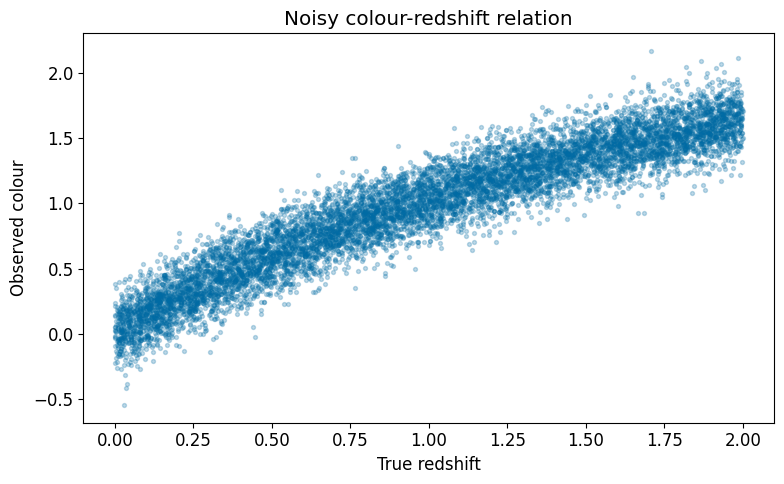

In [4]:
plt.scatter(df["z"], df["color"], s=8, alpha=0.25)
plt.xlabel("True redshift")
plt.ylabel("Observed colour")
plt.title("Noisy colour-redshift relation")
plt.tight_layout()
plt.show()


## 3. Selection Bias and Distribution Shift

###### Spectroscopic incompleteness

Real spectroscopic labels are:

* expensive
* magnitude-limited
* biased toward low redshift

We simulate: $z < 1.2 \quad \text{(training only)}$

while testing on: $z \in [0,2]$


###### Resulting structure

* training distribution ≠ test distribution
* high-redshift regime is unobserved during training
* evaluation mixes interpolation and extrapolation

This creates:

> Support mismatch / truncated training distribution

###### Key consequence

Standard validation only measures:

> interpolation performance inside biased support

It does NOT measure:

* extrapolation ability
* physical generalization
* robustness under survey conditions


In [5]:
mask_train = z < 1.2
# This simulates a spectroscopic completeness limit.
# In real astronomy, distant galaxies (z>1.2) are much fainter.
# To get a "true" redshift label, you need a spectrum.
# If a galaxy is too faint, the telescope can't get a clear spectrum, so that galaxy remains "unlabeled."
# The Result is that the training set is "truncated"—it only knows about the nearby universe.

# Instead of a random 80/20 split, the code sets up two different "worlds":
# Labeled sample
# df_train consisting only in galaxies with z<1.2 and these are the only data the model is allowed to study.
df_train = df[mask_train].copy()
# Full photometric survey population
# df_test consisting in all galaxies (0 to 2) as we are interested in evaluating the model on the whole universe.
df_test = df.copy()


In [6]:
X_labeled = df_train[["color"]]
y_labeled = df_train["z"]

X_train, X_val, y_train, y_val = train_test_split(
    X_labeled,
    y_labeled,
    test_size=0.25,
    random_state=SEED
)

# keep realistic deployment test set = whole survey
X_test = df_test[["color"]]
y_test = df_test["z"]

print("Train size        :", len(X_train))
print("Val size          :", len(X_val))
print("Survey (Test) size:", len(X_test))

print("\nTrain z  min:", round(y_train.min(),3))
print("Val z    min:", round(y_val.min(),3))
print("Survey z min:", round(y_test.min(),3))

print("\nTrain z  max:", round(y_train.max(),3))
print("Val z    max:", round(y_val.max(),3))
print("Survey z max:", round(y_test.max(),3))

Train size        : 4117
Val size          : 1373
Survey (Test) size: 9000

Train z  min: 0.0
Val z    min: 0.0
Survey z min: 0.0

Train z  max: 1.199
Val z    max: 1.199
Survey z max: 1.999


### Checkpoint 2

Compare training and test distributions:

- Does the training set represent the full universe?
- Which region is completely missing?
- What type of prediction will the model make there?

Predict the failure mode before running models.

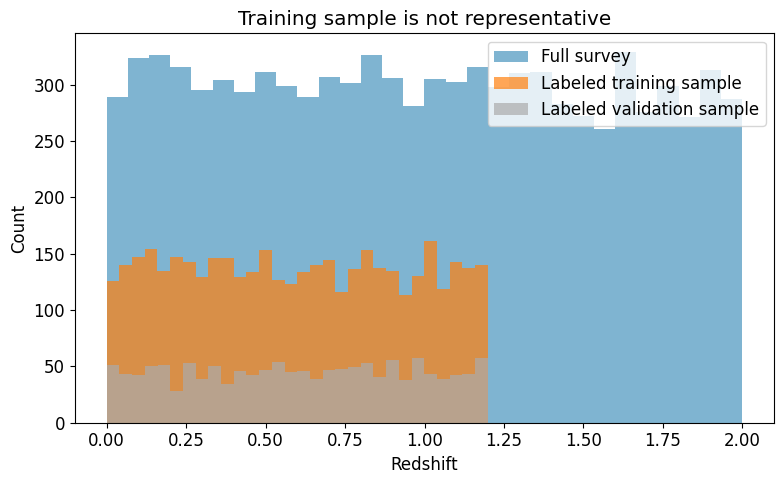

In [7]:
plt.hist(y_test,  bins=30, alpha=0.5, label="Full survey")
plt.hist(y_train, bins=30, alpha=0.7, label="Labeled training sample")
plt.hist(y_val,   bins=30, alpha=0.7, label="Labeled validation sample")

plt.xlabel("Redshift")
plt.ylabel("Count")
plt.title("Training sample is not representative")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Models and Inductive Bias

In this section, we show that algorithms are not neutral. 

Every model carries a set of "preconceptions" (Inductive Bias) that dictate how it behaves when the data runs out.

Specifically, we compare:

* Dummy baseline

* Linear Regression $ \hat{z} = \beta_0 + \beta_1 x$
   - global functional assumption
   - supports extrapolation
   - biased if physics is nonlinear
* Random Forest (piecewise constant where predictions are bounded by training targets)
  - strong interpolation
  - no meaningful extrapolation
  - saturation at training maximum

* Gradient Boosting
  - improves interpolation via sequential correction
  - inherits same bounded-support limitation
  - still fails under extrapolation



###### A. Inductive Bias: The "Preconception"
Inductive bias is the set of assumptions a model uses to predict outputs for inputs it has never seen. 
*   **Linear Regression** has a **Global Bias**: It assumes the universe follows a straight line everywhere.
*   **Tree Models** have a **Local Bias**: They assume the universe is a collection of boxes.

###### B. The Extrapolation Paradox
In astronomy, we often observe the "tail" of a distribution (the faintest, most distant galaxies). 
*   **Linear models** are "brave": they will happily predict a redshift of $z=5.0$ if the line points there, even if they've only seen up to $z=1.0$. They can be **meaningfully wrong**.
*   **Tree models** (Random Forest/GBM) are "cowardly": they cannot predict anything outside the range of their training labels. If your training set ends at $z=1.2$, a Random Forest will predict $z=1.2$ for every galaxy in the distant universe. This is called **Saturation**.

###### C. Why Model Comparison Changes Under Shift
When your training and test sets match, you are testing **Accuracy**. When they don't match (Distribution Shift), you are testing **Assumptions**. You aren't comparing how well the models "learned"; you are comparing which model's "guess" about the unknown is more palatable.


###### D. Models and Inductive Bias: Extrapolation as a Philosophical Choice

We evaluate three architectures with fundamentally different **Inductive Biases** to see how their underlying assumptions dictate scientific results under distribution shift.

| Model | Inductive Bias | Extrapolation Behavior |
| :--- | :--- | :--- |
| **Linear Regression** | Global affine structure ($\hat{z} = \beta_0 + \beta_1 x$) | **Continuous:** Supports extrapolation by extending the global trend. |
| **Random Forest** | Piecewise constant / Bagging | **Bounded:** Saturates at the training maximum; cannot predict outside the label range. |
| **Gradient Boosting** | Sequential residual correction | **Bounded:** Inherits tree limitations; fails to generalize beyond training support. |


### The Core Trade-off: Interpolation vs. Extrapolation

The "best" model depends entirely on which regime of the universe you are analyzing:

###### A. Interpolation (Within Training Support)
Performance is driven by **Variance Reduction** and **Local Smoothing**. Flexible, high-capacity models (Random Forest, Boosting) dominate here because they can "wiggle" to fit the nonlinear physics of the 4000 Å break.

###### B. Extrapolation (Outside Training Support)
There is no data to constrain the model. Predictions depend entirely on the **structural assumptions** of the algorithm:
*   **Linear Regression** assumes the trend is eternal (global affine structure).
*   **Trees/Forests** assume the unseen universe looks exactly like the edge of the seen universe.

> **Scientific Implication:** Under distribution shift, model selection is no longer a search for accuracy—it is a **comparison of assumptions about the unseen universe**. Choosing a model is effectively choosing how you prefer your extrapolation to fail.


In [8]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1
)

lin = LinearRegression()

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=SEED
)

dummy = DummyRegressor(strategy="mean")

models = {
    "Dummy Mean": dummy,
    "Linear": lin,
    "Random Forest": rf,
    "Gradient Boosting": gbr
}

predictions_val = {}
predictions_test = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions_val[name] = model.predict(X_val)
    predictions_test[name] = model.predict(X_test)


#pred_dummy_val  = predictions_val["Dummy Mean"]
#pred_dummy_test = predictions_test["Dummy Mean"]
pred_lin_val  = predictions_val["Linear"]
pred_lin_test = predictions_test["Linear"]
pred_gbr_val  = predictions_val["Gradient Boosting"]
pred_gbr_test = predictions_test["Gradient Boosting"]
pred_rf_val  = predictions_val["Random Forest"]
pred_rf_test = predictions_test["Random Forest"]

print("Models trained:", list(models.keys()))


Models trained: ['Dummy Mean', 'Linear', 'Random Forest', 'Gradient Boosting']


### Checkpoint 3

Before looking at metrics:

- Which model should perform better at high redshift?
- Which model should fail more abruptly?
- Why?

Justify your answer based on inductive bias.

### Prediction vs Color

This plot shifts perspective from **redshift space (z)** to **feature space (color)**.

This matters because:

> Models do not know redshift — they only see color.

###### 1. Training support boundary (vertical lines)

* These mark the **range of colors seen during training**
* Outside this region → **true extrapolation in X**

###### 2. Inside support (interpolation)

* All models behave reasonably
* Differences reflect:

  * flexibility (RF/GBR)
  * bias (linear)

###### 3. Outside support (true extrapolation)

Now the key behaviors emerge:

* **Random Forest / Gradient Boosting**

  * flatten → **constant prediction**
  * caused by leaf averaging
  * no mechanism to extend function

* **Linear Regression**

  * continues trend
  * extrapolates globally

###### Key insight

> The failure is not caused by “missing redshift values.”
> It is caused by **missing regions in feature space (color).**

Importantly, extrapolation is defined in feature space, not redshift space.

A high-redshift galaxy may still fall inside the training color range, and thus be interpolated, while a lower-redshift galaxy with unusual properties may lie outside support and trigger extrapolation.


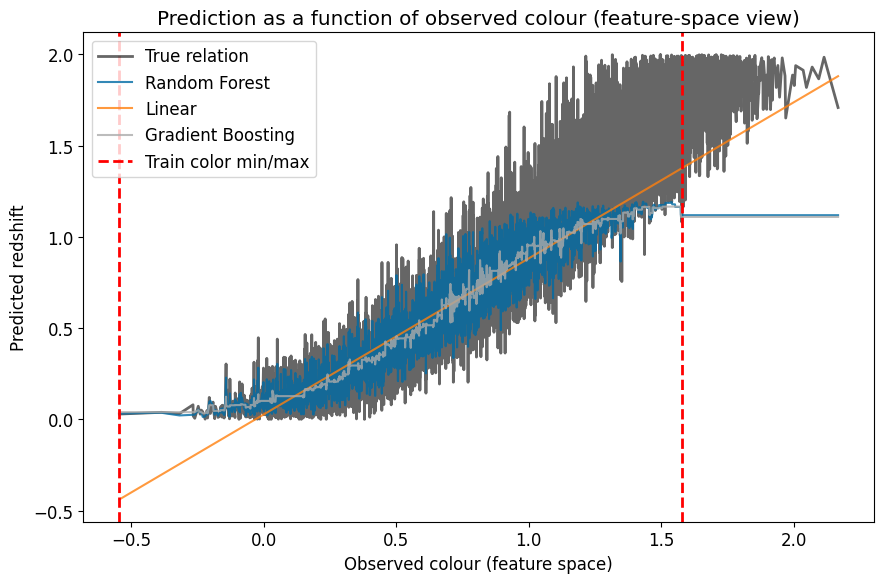

In [9]:
# Sort by color for clean visualization
idx_color = np.argsort(X_test["color"].values)

color_sorted = X_test["color"].values[idx_color]

pred_rf_sorted  = pred_rf_test[idx_color]
pred_lin_sorted = pred_lin_test[idx_color]
pred_gbr_sorted = pred_gbr_test[idx_color]

z_sorted = y_test.values[idx_color]

# Training support in feature space
color_train_min = X_train["color"].min()
color_train_max = X_train["color"].max()

plt.figure(figsize=(9,6))

# True relation (projected)
plt.plot(color_sorted, z_sorted, color="black", lw=2, alpha=0.6, label="True relation")

# Model predictions
plt.plot(color_sorted, pred_rf_sorted,  label="Random Forest", alpha=0.8)
plt.plot(color_sorted, pred_lin_sorted, label="Linear", alpha=0.8)
plt.plot(color_sorted, pred_gbr_sorted, label="Gradient Boosting", alpha=0.8)

# Mark training support in color
plt.axvline(color_train_min, color="red", ls="--", lw=2, label="Train color min/max")
plt.axvline(color_train_max, color="red", ls="--", lw=2)

plt.xlabel("Observed colour (feature space)")
plt.ylabel("Predicted redshift")
plt.title("Prediction as a function of observed colour (feature-space view)")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Why Global Metrics Fail

Consider for example:

$
\mathrm{RMSE} = \sqrt{\mathbb{E}[(\hat{z}-z)^2]}
$

Problem:

* mixes interpolation + extrapolation regimes
* hides structured failure modes

###### Key observation

Global metrics are dominated by the training distribution density.

A model can:

* perform well in-domain
* fail catastrophically out-of-domain

Yet still appear competitive in RMSE.


In [10]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    r2   = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "R2": r2
    }

In [11]:
def styled_table(df_metrics):
    max_bias = df_metrics[['Bias']].abs().max().max() 
    # Create a custom map: Red (at -1) -> Green (at 0) -> Red (at +1)
    colors = ["#e31a1c", "#33a02c", "#e31a1c"] # Red, Green, Red
    rgr_cmap = LinearSegmentedColormap.from_list("RedGreenRed", colors)
    # Create the styled table
    styled_metrics = df_metrics.style
    styled_metrics = styled_metrics.background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE'])
    styled_metrics = styled_metrics.background_gradient(cmap='RdYlGn', subset=['R2'])
    styled_metrics = styled_metrics.background_gradient(
        cmap=rgr_cmap, 
        subset=['Bias'],
        vmin=-max_bias, 
        vmax=max_bias
    )
    styled_metrics = styled_metrics.format(
        lambda x: "{:.3e}".format(x) if (x < -100 or x > 100) else "{:.3f}".format(x))
    return styled_metrics

In [12]:
results_val = []

for name, pred in predictions_val.items():
    results_val.append(evaluate_model(name+" on Validation Set", y_val, pred))

df_metrics_val = pd.DataFrame(results_val).set_index("Model")

display(styled_table(df_metrics_val))


,RMSE,MAE,Bias,R2
Model,,,,
Dummy Mean on Validation Set,0.347,0.300,-0.011,-0.001
Linear on Validation Set,0.144,0.115,0.003,0.827
Random Forest on Validation Set,0.165,0.129,0.003,0.774
Gradient Boosting on Validation Set,0.140,0.110,0.002,0.837


In [13]:
results_test = []

for name, pred in predictions_test.items():
    results_test.append(evaluate_model(name+" on Test Set", y_test, pred))

df_metrics_test = pd.DataFrame(results_test).set_index("Model")

display(styled_table(df_metrics_test))


,RMSE,MAE,Bias,R2
Model,,,,
Dummy Mean on Test Set,0.697,0.575,-0.392,-0.463
Linear on Test Set,0.270,0.208,-0.136,0.781
Random Forest on Test Set,0.342,0.232,-0.189,0.649
Gradient Boosting on Test Set,0.351,0.256,-0.191,0.629


In [14]:
# 1. Define the masks for the two regimes
mask_test_id = y_test < 1.2

# 2. Calculate metrics for each model
results_test_id = []

for name, pred in predictions_test.items():
    results_test_id.append(evaluate_model(name +" on In Domain (Low-z: z<=1.2) Test Set", 
                                          y_test[mask_test_id], pred[mask_test_id]))

df_metrics_test_id = pd.DataFrame(results_test_id).set_index("Model")

display(styled_table(df_metrics_test_id))


,RMSE,MAE,Bias,R2
Model,,,,
Dummy Mean on In Domain (Low-z: z<=1.2) Test Set,0.347,0.301,-0.003,-0.000
Linear on In Domain (Low-z: z<=1.2) Test Set,0.145,0.116,0.001,0.825
Random Forest on In Domain (Low-z: z<=1.2) Test Set,0.099,0.069,0.001,0.920
Gradient Boosting on In Domain (Low-z: z<=1.2) Test Set,0.134,0.105,0.001,0.851


In [15]:
# 1. Define the masks for the two regimes
mask_test_ood = y_test >= 1.2

# 2. Calculate metrics for each model
results_test_ood = []

for name, pred in predictions_test.items():
    results_test_ood.append(evaluate_model(name + " on Out-of-Domain (High-z: z>1.2) Test Set", 
                                  y_test[mask_test_ood], pred[mask_test_ood]))

df_metrics_test_ood = pd.DataFrame(results_test_ood).set_index("Model")

display(styled_table(df_metrics_test_ood))


,RMSE,MAE,Bias,R2
Model,,,,
Dummy Mean on Out-of-Domain (High-z: z>1.2) Test Set,1.029,1.002,-1.002,-18.593
Linear on Out-of-Domain (High-z: z>1.2) Test Set,0.392,0.352,-0.350,-1.842
Random Forest on Out-of-Domain (High-z: z>1.2) Test Set,0.533,0.487,-0.487,-4.263
Gradient Boosting on Out-of-Domain (High-z: z>1.2) Test Set,0.536,0.492,-0.492,-4.325


### Why These Failures Are Hard to Detect

The most important aspect of this problem is not low accuracy. It is that:

> all standard validation metrics appear correct within the training regime.

- validation loss behaves normally  
- residuals look well-behaved in-distribution  
- uncertainty appears calibrated in-domain  

The breakdown becomes visible only when:

- extrapolating beyond training support  
- evaluating full survey populations  
- testing high-redshift regimes  

Scientific ML failures are often invisible under standard evaluation pipelines.


> If your evaluation pipeline only checks if the model is 'right' about the data you already have, you haven't done science. 
<br>You've only done curve-fitting. 
<br>Science happens when you test the model's ability to remain valid in the regimes where labels are hard to get.


## 6. Regime-Based Error Structure

**Support** refers to the region of the feature space (colors) where you have provided the model with training labels.

We separate:

### Interpolation Regime (The Known):

- data-supported
  - The model has seen many examples of galaxies at $z=0.5$ and $z=0.7$
- low bias
  - The model can easily guess what a galaxy at $z=0.6$ looks like.  
- reliable evaluation
  - Evaluation is **reliable** because the test data looks like the training data. 
### - Extrapolation regime

- unsupported
  - The model is being asked to predict a galaxy at $z=1.8$ when its "worldview" stops at $z=1.2$.
- model-driven behavior dominated by inductive bias
  - Evaluation here is **critical** because it reveals the model's true nature.

### Key result

#### **Tree-Based Models (Random Forest/Grad Boost): The "Ceiling" Effect**
Trees work by splitting data into boxes and averaging the labels inside those boxes. 
*   **The Trap:** A tree cannot mathematically predict a value it has never seen. If the highest redshift in your training set is $z=1.2$, the "highest" box the tree can create is "average of galaxies near 1.2."
*   **Saturation:** When you feed it a galaxy from $z=1.8$, the tree puts it in that "1.2 box." This creates a **saturation ceiling**.
*   **Scientific Result:** They **systematically underestimate** the distance of far-away objects. In a real survey, this would cause you to "clump" all distant galaxies at a single fake distance, ruining your map of the large-scale structure of the universe.

#### **Linear Models: The "Consistency" Effect**
Linear models don't care about the boundaries of your training set; they care about the **slope**.
*   **The Advantage:** If the color-redshift relation is roughly linear, the model will "shoot the gap" into the unknown. It will predict $z=1.8$ because the line keeps going up.
*   **Smoother Bias:** The error doesn't suddenly "hit a wall." Instead, the bias grows or shrinks gradually depending on how much the true physics deviates from a straight line.
*   **Scientific Result:** They provide better **global trend consistency**, making them often more "useful" for high-redshift discovery than a complex but bounded Random Forest.


###### The Inductive Bias Choice

> If you choose a Random Forest for your survey, you are assuming that anything you haven't seen yet is exactly like the things you have already seen. If you choose a Linear Model, you are assuming that the laws of physics don't change just because your telescope got tired. One is a **conservative bias** (Trees), the other is a **structural bias** (Linear).


## Gold-standard diagnostic: interpolation vs extrapolation

We explicitly mark where the model is supported by data vs where it is extrapolating.

**What to look for:**
- Vertical line at training limit (z = 1.2)
- Model behavior changes qualitatively beyond this boundary
- Saturation or divergence appears only in the extrapolation region

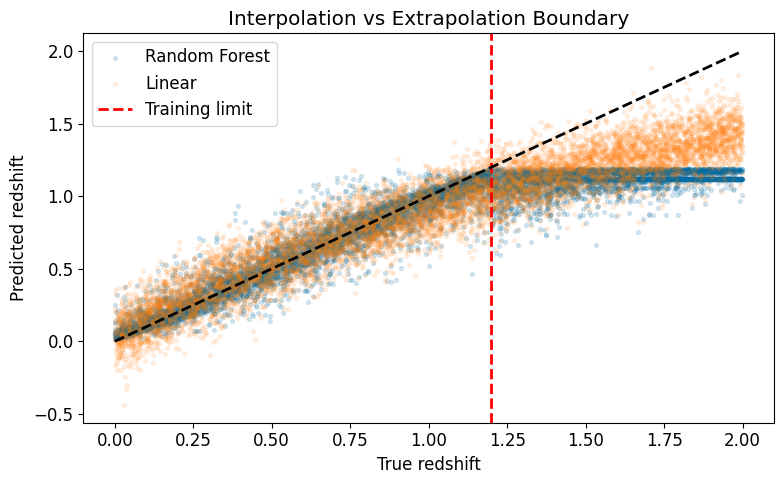

In [16]:
plt.scatter(y_test, pred_rf_test, s=8, alpha=0.15, label="Random Forest")
plt.scatter(y_test, pred_lin_test, s=8, alpha=0.10, label="Linear")

plt.axvline(1.2, color="red", linestyle="--", lw=2, label="Training limit")
plt.plot([0,2],[0,2], "k--", lw=2)

plt.xlabel("True redshift")
plt.ylabel("Predicted redshift")
plt.title("Interpolation vs Extrapolation Boundary")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Residuals and Systematic Bias

Residual: $r = \hat{z} - z$

Ideal:

* zero mean
* no dependence on z

Observed:

###### Tree models

* strong negative bias at high z
* linear divergence due to saturation

###### Linear model

* smooth structured bias across range


### Key insight

> Systematic bias often dominates downstream cosmological inference.

## Gold-standard diagnostic: bias as a function of redshift

We measure systematic error as a function of the physical variable.

**What to look for:**
- Flat line at 0 → unbiased model
- Downward slope at high z → systematic underestimation
- Sharp deviation indicates extrapolation failure

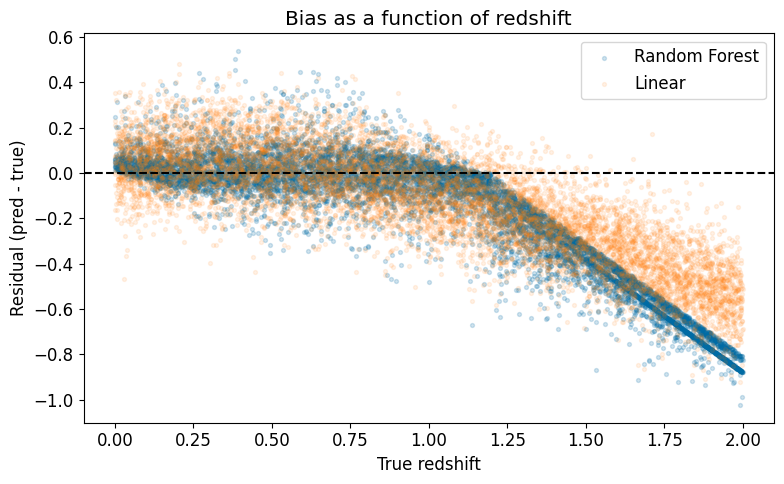

In [17]:
resid_rf_test = pred_rf_test - y_test
resid_lin_test = pred_lin_test - y_test

plt.scatter(y_test, resid_rf_test, s=8, alpha=0.18, label="Random Forest")
plt.scatter(y_test, resid_lin_test, s=8, alpha=0.10, label="Linear")

plt.axhline(0, color="black", ls="--")

plt.xlabel("True redshift")
plt.ylabel("Residual (pred - true)")
plt.title("Bias as a function of redshift")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
def binned_bias(y_true, y_pred):
    idx = np.digitize(y_true, bins)
    vals = []
    for i in range(1, len(bins)):
        m = idx == i
        vals.append(np.mean(y_pred[m] - y_true[m]) if m.sum() > 0 else np.nan)
    return np.array(vals)


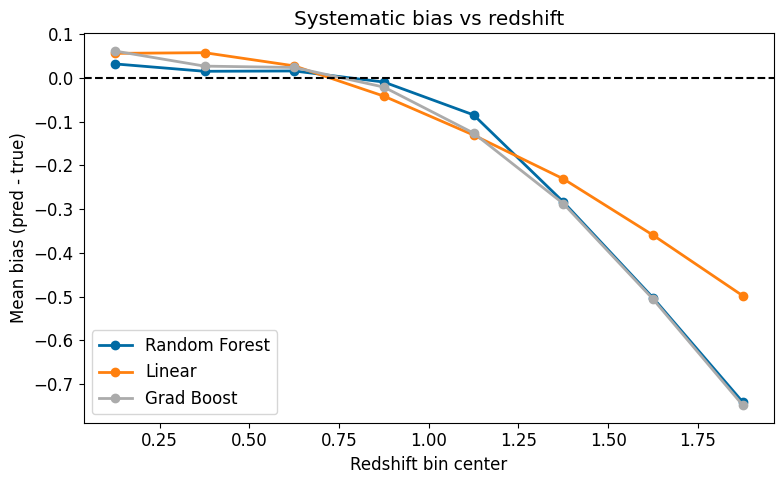

In [19]:
bins = np.linspace(0, 2.0, 9)
centers = 0.5 * (bins[:-1] + bins[1:])

bias_rf_test  = binned_bias(y_test.values, pred_rf_test)
bias_lin_test = binned_bias(y_test.values, pred_lin_test)
bias_gbr_test = binned_bias(y_test.values, pred_gbr_test)

plt.plot(centers, bias_rf_test,  "o-", lw=2, label="Random Forest")
plt.plot(centers, bias_lin_test, "o-", lw=2, label="Linear")
plt.plot(centers, bias_gbr_test, "o-", lw=2, label="Grad Boost")

plt.axhline(0, color="black", ls="--")
plt.xlabel("Redshift bin center")
plt.ylabel("Mean bias (pred - true)")
plt.title("Systematic bias vs redshift")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Uncertainty and Calibration

We use ensemble variance: $\sigma(x) = \mathrm{std}(\text{trees})$

* epistemic uncertainty within training support

Notice that this is a heuristic proxy for model uncertainty.

###### Failure mode

In extrapolation:

* predictions collapse
* variance collapses
* true error increases

So:

$
\sigma(x) \downarrow \quad \text{while} \quad |\hat{z}-z| \uparrow
$

This produces:

> overconfidence under domain shift

###### Calibration test

* predicted uncertainty $\neq$ true error
* coverage collapses in OOD region
* $\sigma$ is not a measure of epistemic uncertainty outside support


In [20]:
# 1. Calculate the Error and the Uncertainty Proxy
# We use the standard deviation of the individual trees as our uncertainty proxy
all_tree_preds = np.stack([tree.predict(X_test.values) for tree in rf.estimators_], axis=0)

mean_pred_rf = all_tree_preds.mean(axis=0)
std_pred_rf = all_tree_preds.std(axis=0)

print("Mean ensemble spread:", round(std_pred_rf.mean(),4))


Mean ensemble spread: 0.0738


The following plot provides a visual representation of how a model's physical understanding literally "hits a wall" while its uncertainty estimation fails to signal the danger.

By sorting the galaxies by their **true redshift**, we are essentially creating a "timeline" of the universe, from nearby ($z=0$) to the cosmic horizon ($z=2$).

###### 1. The "Saturation" Ceiling (The Orange Line)
The orange line (RF Prediction) follows the blue line (True Redshift) beautifully at the start. However, look at what happens exactly at **$z=1.2$**:
*   The blue line continues to climb linearly toward the distant universe.
*   The orange line **flattens out** into a horizontal plateau.
*   **Scientific Meaning:** The Random Forest has reached its "knowledge limit." Because it never saw galaxies at $z > 1.2$ during training, it cannot "imagine" them. It predicts the highest value it knows ($1.2$) for every single galaxy beyond that point.

###### 2. The Illusion of Certainty (The Shaded Region)
The shaded area represents the **Ensemble Spread** (the standard deviation between all 300 trees in your forest).
*   **In-Domain ($z < 1.2$):** The shaded region is relatively wide and correctly "hugs" the true blue line. The model knows it might be off by $\pm 0.1$, and the truth is usually within that window.
*   **Out-of-Domain ($z > 1.2$):** Notice how the shaded region **shrinks** or stays narrow even as the blue line escapes it. 
*   **The Paradox:** Even though the error (the distance between blue and orange) is growing massively, the model's disagreement (the shade) is small. All 300 trees are "unanimously wrong."

###### 3. The "Sorting" Logic: Why `argsort`?
Sorting by the **True Redshift** is a clever diagnostic trick. 
*   If you didn't sort the data, the plot would be a chaotic jumble of 6,000 points. 
*   By sorting, you force the x-axis to represent a physical progression. It makes the **breakdown point** ($z=1.2$) look like a physical phase transition in the model's performance.

###### Summary 
> Look at the right side of the plot. The gap between the blue and orange lines is the **Scientific Bias**. The fact that the shaded region doesn't widen to cover that gap is the **Overconfidence**. In this regime, the model is providing a high-precision answer to the wrong question, which is the most dangerous kind of error in astrophysics.


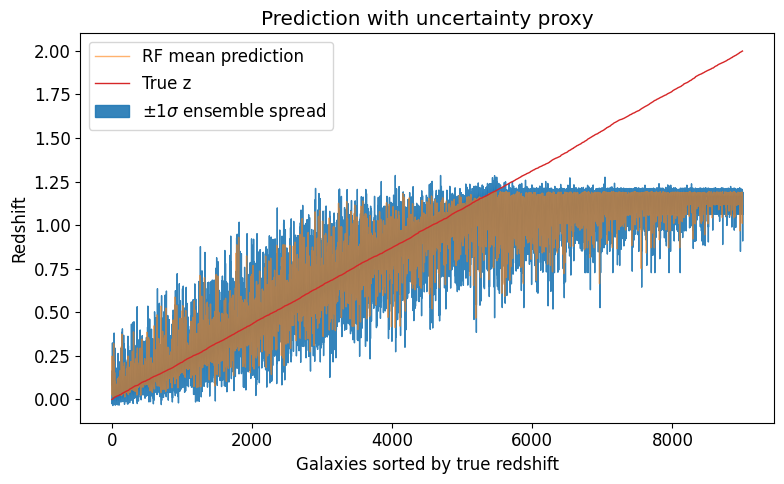

In [21]:
idx = np.argsort(y_test.values)

plt.plot(mean_pred_rf[idx], label="RF mean prediction", lw=1, alpha=0.6,color="tab:orange")

plt.plot(y_test.values[idx], label="True z", lw=1,color="tab:red")

plt.fill_between(
    np.arange(len(idx)),
    mean_pred_rf[idx] - std_pred_rf[idx],
    mean_pred_rf[idx] + std_pred_rf[idx],
    alpha=0.9,
    label=r"$\pm 1 \sigma$ ensemble spread",color="tab:blue")


plt.xlabel("Galaxies sorted by true redshift")
plt.ylabel("Redshift")
plt.title("Prediction with uncertainty proxy")
plt.legend()
plt.tight_layout()
plt.show()


### Gold-standard diagnostic: uncertainty collapse

In science, we don't just care if a model is right; we care if the model **knows when it is wrong**.

The following plot exposes the "Uncertainty Collapse", i.e. the moment a machine learning model becomes a "liar" by providing a very precise (low $\sigma$) answer that is significantly incorrect (high error).

###### 1. The Anatomy of the Axes
*   **X-axis (Predicted Uncertainty):** This is the model’s internal "confidence meter" (the standard deviation between the trees in the Random Forest). A small value means the trees all agree.
*   **Y-axis (Realized Error):** This is the "ground truth" error ($|\hat{z} - z|$). It tells us how far the model actually was from reality.
*   **The Diagonal Dashed Line:** This represents the **Ideal Calibration**. Points on this line are "honest"—the model's predicted uncertainty perfectly matches its actual error.

###### 2. The Teal Cloud: "Honest" Interpolation
The teal points represent galaxies within the training regime ($z < 1.2$).
*   They mostly cluster at the bottom-left or along the diagonal.
*   **Interpretation:** When the model is in a regime it understands, its errors are small, and its predicted uncertainty is appropriately small. If it makes a larger error, the uncertainty usually increases to reflect that. The model is **trustworthy**.

###### 3. The Crimson Cloud: The "Collapse"
The red points represent galaxies in the extrapolation regime ($z \ge 1.2$).
*   **The Failure:** Notice that these points have shifted to the **top-left**.
*   **The Paradox:** Their **X-values (Uncertainty) are low**, meaning the model is very confident. However, their **Y-values (Error) are high**, meaning the model is catastrophically wrong.
*   **Why does this happen?** Because every tree in the Random Forest is hitting the same "saturation ceiling" at $z=1.2$. Since they all hit the same wall, they all agree with each other. The ensemble spread (uncertainty) collapses to zero, even though the physics is being ignored.

###### 4. The "Danger Zone"
The red shaded box highlights the most scientifically dangerous outcome: **Overconfidence**.
*   Any galaxy in this box will be passed into a cosmological pipeline with a "high weight" because the model claims to be certain.
*   **Scientific Result:** This leads to "Precision Bias"—obtaining a result with very small error bars that is nowhere near the true value of the physical constant you are trying to measure.

###### Summary:
> In astronomy, a model that is wrong but knows it (high $\sigma$) is manageable. A model that is wrong but thinks it is right (the Crimson Cloud) is a disaster. This plot is how you catch the disaster before you publish it.

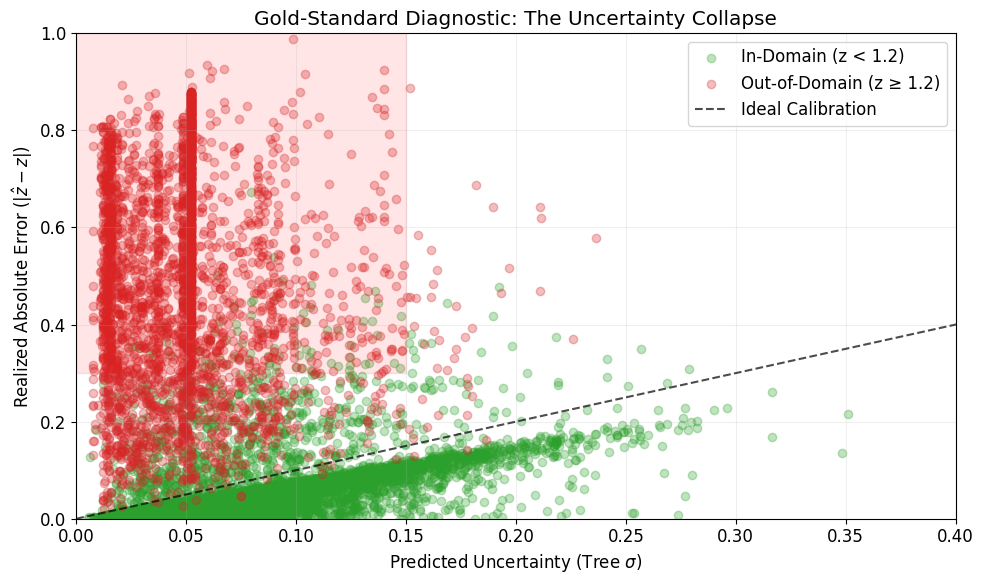

In [22]:
abs_err_rf = np.abs(pred_rf_test - y_test)

plt.figure(figsize=(10, 6))

# 3. Plot Individual Galaxies
plt.scatter(std_pred_rf[mask_test_id],  abs_err_rf[mask_test_id], color='tab:green', alpha=0.3, label='In-Domain (z < 1.2)')
plt.scatter(std_pred_rf[mask_test_ood], abs_err_rf[mask_test_ood], color='tab:red', alpha=0.3, label='Out-of-Domain (z ≥ 1.2)')

# 4. Add the "Ideal" line where Uncertainty == Error
max_val_rf = max(std_pred_rf.max(), abs_err_rf.max())
plt.plot([0, max_val_rf], [0, max_val_rf], 'k--', alpha=0.7, label='Ideal Calibration')

# 5. Formatting the "Danger Zone"
plt.fill_between([0, 0.15], 0.3, max_val_rf, color='red', alpha=0.1)

plt.xlim(0, 0.4)
plt.ylim(0, 1.0)
plt.xlabel("Predicted Uncertainty (Tree $\sigma$)")
plt.ylabel("Realized Absolute Error ($|\hat{z} - z|$)")
plt.title("Gold-Standard Diagnostic: The Uncertainty Collapse")
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [23]:
# Overconfidence test: If uncertainty were reliable, many true values should lie inside ±1σ.

inside = (
    (y_test[mask_test_ood] >= mean_pred_rf[mask_test_ood] - std_pred_rf[mask_test_ood]) &
    (y_test[mask_test_ood] <= mean_pred_rf[mask_test_ood] + std_pred_rf[mask_test_ood])
)

coverage = inside.mean()

print("Fraction of z > 1.2 objects inside ±1σ interval:", round(float(coverage),4))


Fraction of z > 1.2 objects inside ±1σ interval: 0.0037


To determine if the model’s internal uncertainty ($\sigma$) is a reliable predictor of its actual performance, we perform the following steps:

- Quantile Binning: It divides the galaxies into 7 equal-sized groups (quantiles) based on their predicted uncertainty (std_pred). This ensures each bin has a statistically significant number of samples.

- Averaging: Within each bin, it calculates the Mean Predicted σ (what the model thinks the error is) vs. the Mean Absolute Error (what the error actually is).

- Diagonal Comparison: It plots these averages against a 1:1 identity line (the dashed black line).

Then we consider the model: 

- Well-Calibrated: If the points follow the diagonal, the model’s "error bars" are physically meaningful. It correctly estimates its own limitations.

- Overconfident: If the points lie above the diagonal, the realized errors are much larger than the predicted σ. This is a red flag, indicating the model is underestimating its own noise or failing to account for distribution shift.

- Underconfident: If the points lie below the diagonal, the model is being overly cautious, providing error bars that are larger than necessary.

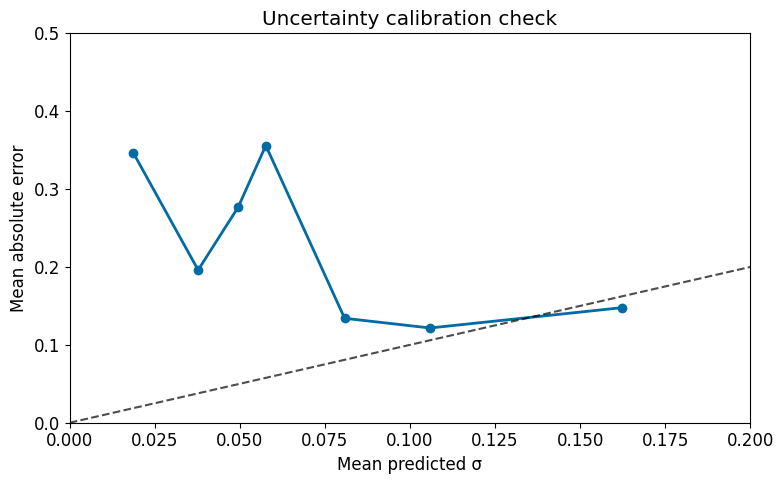

In [24]:
# ## Calibration diagnostic
#
# If predicted uncertainty is meaningful, larger predicted sigma should correspond to larger realized errors.


bins_rf = np.quantile(std_pred_rf, np.linspace(0,1,8))
bins_rf[0] -= 1e-8
bins_rf[-1] += 1e-8

digitized_rf= np.digitize(std_pred_rf, bins_rf)

x_sigma_rf = []
y_err_rf = []

for i in range(1, len(bins_rf)):
    m_rf = digitized_rf == i
    if m_rf.sum() > 10:
        x_sigma_rf.append(std_pred_rf[m_rf].mean())
        y_err_rf.append(abs_err_rf[m_rf].mean())

plt.plot(x_sigma_rf, y_err_rf, "o-", lw=2)
#plt.plot([0,max(x_sigma)], [0,max(x_sigma)], "k--", alpha=0.6)

plt.plot([0, max_val_rf], [0, max_val_rf], 'k--', alpha=0.7, label='Ideal Calibration')
plt.xlim(0, 0.2)
plt.ylim(0, 0.5)
plt.xlabel("Mean predicted σ")
plt.ylabel("Mean absolute error")
plt.title("Uncertainty calibration check")
plt.tight_layout()
plt.show()


### Checkpoint 4

Interpret uncertainty:

- Does low predicted σ always mean low error?
- What happens to σ in regions without training data?
- What kind of uncertainty is missing here?

Explain in terms of epistemic vs aleatoric uncertainty.

## NGBoost Baseline: Probabilistic Gradient Boosting

We introduce **Natural Gradient Boosting for Regression (NGBoost)** as a robust probabilistic baseline. NGBoost bridges the gap between high-performance tree ensembles and rigorous statistical inference.

Unlike standard tree ensembles (like Random Forest or XGBoost):

*   **Explicit Distributional Output:** NGBoost does not just predict a point estimate; it treats the parameters of the target distribution—the mean ($\mu$) and the standard deviation ($\sigma$)—as separate targets to be optimized.
*   **Natural Gradient Optimization:** It employs the **Natural Gradient**, which accounts for the geometry of the probability space. This ensures that updates to the model's "confidence" ($\sigma$) are statistically stable and mathematically grounded.
*   **Heteroscedastic Uncertainty:** The model naturally learns that some regions of the feature space (e.g., specific color-magnitude ranges) are inherently noisier than others, assigning a unique uncertainty to every individual galaxy.

This allows us to compare:

*   **Random Forest** $\rightarrow$ Empirical interpolation (often yields "collapsed" or overconfident uncertainty).
*   **NGBoost** $\rightarrow$ Probabilistic boosting (delivers a calibrated predictive distribution that quantifies the model's reliability across different redshift regimes).

In [25]:
from sklearn.gaussian_process.kernels import RBF, DotProduct, ConstantKernel as C, WhiteKernel

# 1. The Kernel Strategy:
# RBF: Handles the local 'wiggles' in color-z space.
# DotProduct: Allows the model to follow a linear trend into high-z (Extrapolation).
# WhiteKernel: Explicitly models the noise floor to prevent overconfidence.
#kernel = (C(1.0, (1e-2, 1e2)) * RBF(length_scale=1.0) + 
#          DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-2, 1e1)) + 
#          WhiteKernel(noise_level=0.05))

#gp = GaussianProcessRegressor(
#    kernel=kernel,
#    alpha=0.0, # We use WhiteKernel instead of alpha for better tuning
#    n_restarts_optimizer=5, # More restarts to handle the complex kernel surface
#    normalize_y=True,
#    random_state=SEED
#)
#gp.fit(X_train, y_train)
#
#gp_mean, gp_std = gp.predict(X_test, return_std=True)

from ngboost import NGBRegressor
from ngboost.distns import Normal
from sklearn.tree import DecisionTreeRegressor

from ngboost import NGBRegressor
from ngboost.distns import Normal
from sklearn.tree import DecisionTreeRegressor
from ngboost.scores import LogScore  # <--- Add this line
ngb = NGBRegressor(
    Dist=Normal, 
    n_estimators=10000, 
    learning_rate=0.001,      
    Base=DecisionTreeRegressor(
        max_depth=4, 
        min_samples_leaf=15,   
        max_features='sqrt'   
    ),
    col_sample=0.7, # This IS a valid NGBoost parameter
    verbose_eval=100           
)
ngb.fit(
    X_train, y_train, 
    X_val=X_val, Y_val=y_val, 
    # At lr=0.001, the model moves slowly. 
    # Give it 300-500 rounds to prove it can't improve anymore.
    early_stopping_rounds=400 
)

# Get both mean and standard deviation instantly
preds_ngb_test = ngb.pred_dist(X_test)
mean_pred_ngb = preds_ngb_test.loc
std_pred_ngb = preds_ngb_test.scale



[iter 0] loss=0.3619 val_loss=0.3590 scale=2.0000 norm=1.0448
[iter 100] loss=0.2010 val_loss=0.1996 scale=2.0000 norm=0.8803
[iter 200] loss=0.0898 val_loss=0.0891 scale=2.0000 norm=0.8274
[iter 300] loss=0.0001 val_loss=-0.0002 scale=2.0000 norm=0.8116
[iter 400] loss=-0.0774 val_loss=-0.0771 scale=2.0000 norm=0.8084
[iter 500] loss=-0.1464 val_loss=-0.1454 scale=2.0000 norm=0.8091
[iter 600] loss=-0.2086 val_loss=-0.2066 scale=2.0000 norm=0.8108
[iter 700] loss=-0.2648 val_loss=-0.2617 scale=2.0000 norm=0.8126
[iter 800] loss=-0.3156 val_loss=-0.3110 scale=2.0000 norm=0.8144
[iter 900] loss=-0.3614 val_loss=-0.3550 scale=2.0000 norm=0.8165
[iter 1000] loss=-0.4023 val_loss=-0.3939 scale=2.0000 norm=0.8193
[iter 1100] loss=-0.4389 val_loss=-0.4280 scale=2.0000 norm=0.8228
[iter 1200] loss=-0.4712 val_loss=-0.4577 scale=2.0000 norm=0.8271
[iter 1300] loss=-0.4997 val_loss=-0.4834 scale=2.0000 norm=0.8324
[iter 1400] loss=-0.5245 val_loss=-0.5051 scale=2.0000 norm=0.8388
[iter 1500] lo

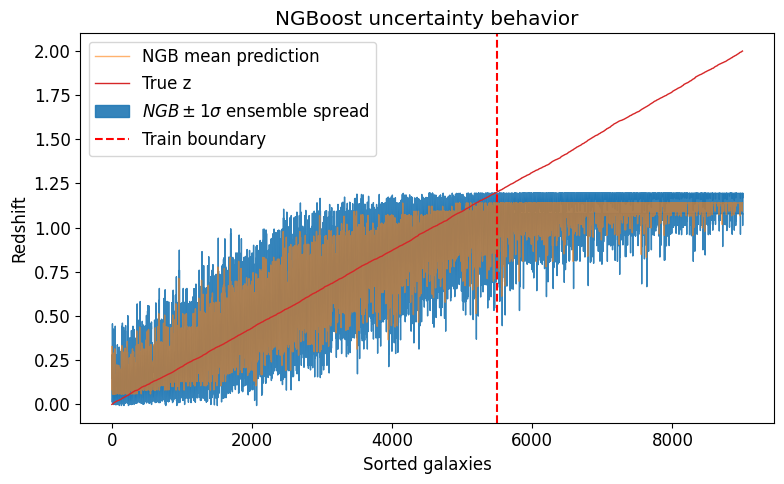

In [26]:
idx = np.argsort(y_test.values)

plt.plot(mean_pred_ngb[idx], label="NGB mean prediction", lw=1, alpha=0.6,color="tab:orange")

plt.plot(y_test.values[idx], label="True z", lw=1,color="tab:red")

plt.fill_between(
    np.arange(len(idx)),
    mean_pred_ngb[idx] - std_pred_ngb[idx],
    mean_pred_ngb[idx] + std_pred_ngb[idx],
    alpha=0.9,
    label=r"$NGB \pm 1 \sigma$ ensemble spread",color="tab:blue")


plt.axvline(np.sum(y_test.values[idx] < 1.2), color="red", ls="--", label="Train boundary")

plt.xlabel("Sorted galaxies")
plt.ylabel("Redshift")
plt.title("NGBoost uncertainty behavior")
plt.legend()
plt.tight_layout()
plt.show()


## NGBoost vs. Random Forest

**What to look for:**

*   **NGBoost Uncertainty Scaling:** Unlike standard boosting, NGBoost utilizes a natural gradient to scale the predictive distribution. We expect to see the predicted $\sigma$ expand or shift as the model encounters sparse or high-redshift regions, reflecting a more sophisticated grasp of **epistemic uncertainty**.
*   **Random Forest Uncertainty Collapse:** Standard tree ensembles often suffer from "arrogance" in the extrapolation regime. Because they rely on the variance of leaf nodes that have never seen high-redshift data, their uncertainty typically collapses, providing high-confidence predictions for significantly incorrect values.
*   **Calibration of the "Danger Zone":** This comparison highlights the difference between **empirical interpolation** (RF) and **probabilistic boosting** (NGBoost). We are looking for whether NGBoost can correctly signal its own "ignorance" when the physics of the universe deviates from the training set.

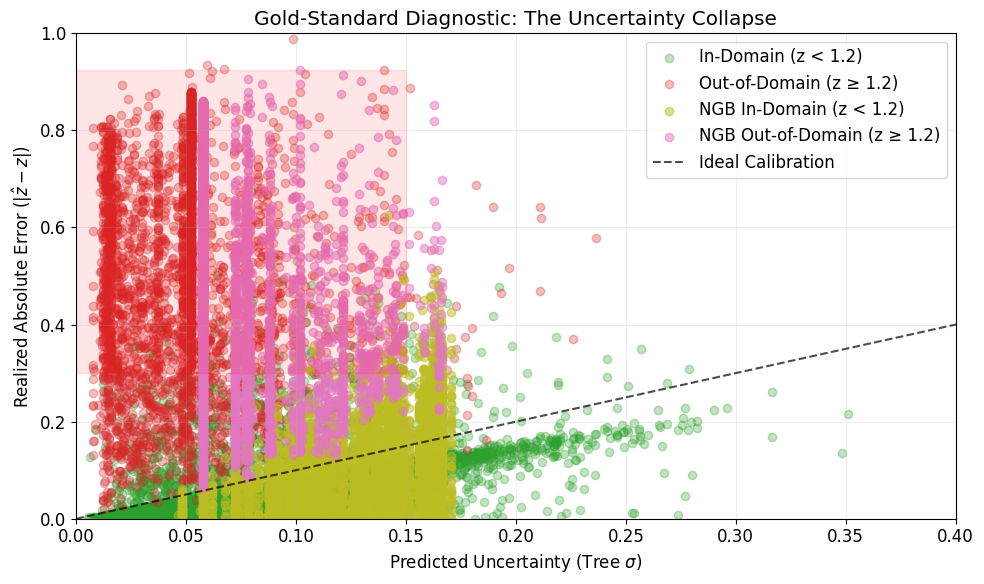

In [27]:
abs_err_ngb = np.abs(mean_pred_ngb - y_test.values)

plt.figure(figsize=(10, 6))

# 3. Plot Individual Galaxies
plt.scatter(std_pred_rf[mask_test_id], abs_err_rf[mask_test_id], color='tab:green', alpha=0.3, label='In-Domain (z < 1.2)')
plt.scatter(std_pred_rf[mask_test_ood], abs_err_rf[mask_test_ood], color='tab:red', alpha=0.3, label='Out-of-Domain (z ≥ 1.2)')

plt.scatter(std_pred_ngb[mask_test_id],  abs_err_ngb[mask_test_id],  color='tab:olive', alpha=0.5, label='NGB In-Domain (z < 1.2)')
plt.scatter(std_pred_ngb[mask_test_ood], abs_err_ngb[mask_test_ood], color='tab:pink', alpha=0.5, label='NGB Out-of-Domain (z ≥ 1.2)')



# 4. Add the "Ideal" line where Uncertainty == Error
max_val_ngb = max(std_pred_ngb.max(), abs_err_ngb.max())
plt.plot([0, max_val_ngb], [0, max_val_ngb], 'k--', alpha=0.7, label='Ideal Calibration')

# 5. Formatting the "Danger Zone"
plt.fill_between([0, 0.15], 0.3, max_val_ngb, color='red', alpha=0.1)

plt.xlim(0, 0.4)
plt.ylim(0, 1.0)
plt.xlabel("Predicted Uncertainty (Tree $\sigma$)")
plt.ylabel("Realized Absolute Error ($|\hat{z} - z|$)")
plt.title("Gold-Standard Diagnostic: The Uncertainty Collapse")
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

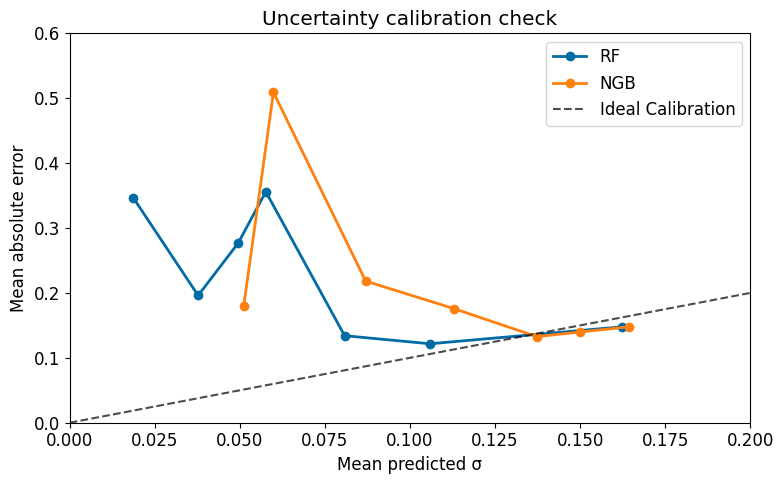

In [28]:
bins_ngb = np.quantile(std_pred_ngb, np.linspace(0,1,8))

bins_ngb[0] -= 1e-8
bins_ngb[-1] += 1e-8

digitized_ngb = np.digitize(std_pred_ngb, bins_ngb)

x_sigma_ngb = []
y_err_ngb = []

for i in range(1, len(bins_ngb)):
    m_ngb = digitized_ngb == i
    if m_ngb.sum() > 10:
        x_sigma_ngb.append(std_pred_ngb[m_ngb].mean())
        y_err_ngb.append(abs_err_ngb[m_ngb].mean())

plt.plot(x_sigma_rf, y_err_rf, "o-", lw=2, label="RF")
plt.plot(x_sigma_ngb, y_err_ngb, "o-", lw=2, label="NGB")

plt.plot([0, max_val_ngb], [0, max_val_ngb], 'k--', alpha=0.7, label='Ideal Calibration')
plt.xlim(0, 0.2)
plt.ylim(0, 0.6)
plt.legend()
plt.xlabel("Mean predicted σ")
plt.ylabel("Mean absolute error")
plt.title("Uncertainty calibration check")
plt.tight_layout()
plt.show()



## 9. Failure Modes in Astronomical ML

### 9.1 A Hierarchical View of Failure

Not all errors in scientific ML are equally fundamental. Failures occur at three levels:

###### Level 1 — Structural (Most Fundamental)

Arise from the data-generating process:

- selection bias (non-representative training sample)  
- incomplete observational support (e.g. missing high-z labels)  
- hidden / latent variables (e.g. dust, environment)  

These determine what is *in principle learnable*.

> If Level 1 fails, no model can recover the true distribution.

###### Level 2 — Representational (Observation Limits)

Arise from how the universe is measured:

- photometric compression of spectra  
- degeneracy in observables (many-to-one mappings)  
- limited or missing features  

These determine whether the inverse problem is identifiable.

###### Level 3 — Algorithmic (Model Choice)

Arise from the learning algorithm:

- linear vs nonlinear assumptions  
- tree ensembles vs parametric models  
- inductive bias differences  

These determine how well structure is fit *within observed support*.

### 9.2 Mapping to Concrete Failure Modes

These levels manifest as the following practical issues:

- **Selection bias** → training sample not representative of the universe  
- **Distribution shift** → test population extends beyond training support  
- **Extrapolation failure** → tree-based models saturate at training bounds  
- **Hidden variables** → missing physics induces degeneracy  

### 9.3 Key Insight

Most ML evaluation emphasizes Level 3 (models),  
while scientific failure is dominated by Levels 1–2 (data + physics).

> Better models cannot fix missing data or missing physics.

Training colour range: -0.545 to 1.577
OOD fraction in survey: 0.0879


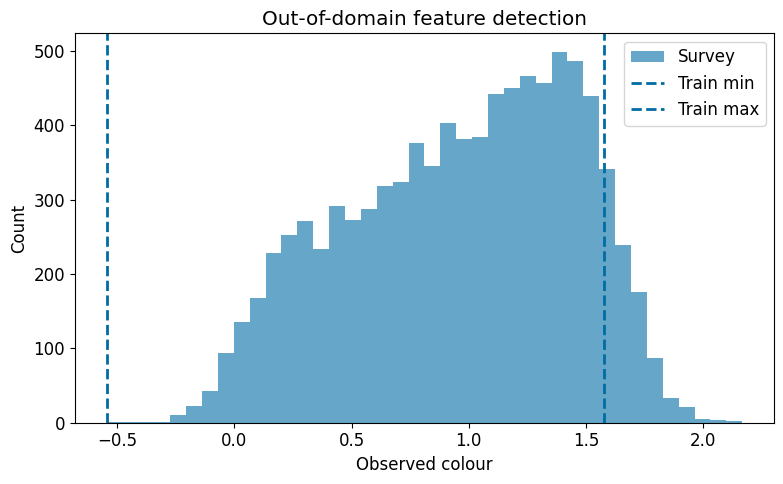

In [29]:

train_min = X_train["color"].min()
train_max = X_train["color"].max()
ood_mask = ((X_test["color"] < train_min) | (X_test["color"] > train_max))
print("Training colour range:", round(train_min,3), "to", round(train_max,3))
print("OOD fraction in survey:", round(ood_mask.mean(),4))
plt.hist(X_test["color"], bins=40, alpha=0.6, label="Survey")
plt.axvline(train_min, ls="--", lw=2, label="Train min")
plt.axvline(train_max, ls="--", lw=2, label="Train max")
plt.xlabel("Observed colour")
plt.ylabel("Count")
plt.title("Out-of-domain feature detection")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Feature Completeness: Dust Example

Extended model:

$
\text{color} = 1.5 \log(1+z) + 0.9,\text{dust} + \epsilon
$

Key result:

* adding dust reduces degeneracy
* improves identifiability
* reduces conditional entropy:

$
H(z \mid x)
$

###### Insight

> Better features improve inference more than better models when the problem is underdetermined.



In [30]:
dust = np.random.exponential(scale=0.12, size=N)

color_dust = 1.5*np.log1p(z) + 0.9*dust + np.random.normal(0,0.15,N)

df_dust = pd.DataFrame({
    "color": color_dust,
    "z": z,
    "dust": dust
})


In [31]:
train_dust = df_dust[mask_train]
test_dust = df_dust.copy()

# model WITHOUT dust feature
X_train_without_dust = train_dust[["color"]]
X_test_without_dust = test_dust[["color"]]

# model WITH dust feature
X_train_with_dust = train_dust[["color","dust"]]
X_test_with_dust = test_dust[["color","dust"]]

y_train_dust = train_dust["z"]
y_test_dust = test_dust["z"]


In [32]:
rf_without_dust = RandomForestRegressor(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1
)

rf_with_dust = RandomForestRegressor(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1
)



models_dust = {
    "RF Without Dust": rf_without_dust,
    "RF With Dust": rf_with_dust,
}

predictions_test_dust = {}

rf_without_dust.fit(X_train_without_dust, y_train_dust)
rf_with_dust.fit(X_train_with_dust, y_train_dust)

pred_rf_without_dust = rf_without_dust.predict(X_test_without_dust)
pred_rf_with_dust = rf_with_dust.predict(X_test_with_dust)

predictions_test_dust["RF Without Dust"] = pred_rf_without_dust
predictions_test_dust["RF With Dust"] = pred_rf_with_dust

print("Models trained:", list(models_dust.keys()))



Models trained: ['RF Without Dust', 'RF With Dust']


In [33]:
results_test_dust = []

for name, pred in predictions_test_dust.items():
    results_test_dust.append(evaluate_model(name+" on Test Set", y_test, pred))

df_metrics_test_dust = pd.DataFrame(results_test_dust).set_index("Model")

display(styled_table(df_metrics_test_dust))


,RMSE,MAE,Bias,R2
Model,,,,
RF Without Dust on Test Set,0.377,0.249,-0.215,0.572
RF With Dust on Test Set,0.343,0.223,-0.196,0.646


In [34]:
results_test_dust_id = []

for name, pred in predictions_test_dust.items():
    results_test_dust_id.append(evaluate_model(name +" on In Domain (Low-z: z<=1.2) Test Set", y_test[mask_test_id], pred[mask_test_id]))

df_metrics_test_dust_id = pd.DataFrame(results_test_dust_id).set_index("Model")

display(styled_table(df_metrics_test_dust_id))


,RMSE,MAE,Bias,R2
Model,,,,
RF Without Dust on In Domain (Low-z: z<=1.2) Test Set,0.073,0.056,0.000,0.956
RF With Dust on In Domain (Low-z: z<=1.2) Test Set,0.057,0.044,-0.000,0.973


In [35]:
results_test_dust_ood = []

for name, pred in predictions_test_dust.items():
    results_test_dust_ood.append(evaluate_model(name + " on Out-of-Domain (High-z: z>1.2) Test Set", 
                                  y_test[mask_test_ood], pred[mask_test_ood]))

df_metrics_test_dust_ood = pd.DataFrame(results_test_dust_ood).set_index("Model")

display(styled_table(df_metrics_test_dust_ood))


,RMSE,MAE,Bias,R2
Model,,,,
RF Without Dust on Out-of-Domain (High-z: z>1.2) Test Set,0.597,0.551,-0.551,-5.594
RF With Dust on Out-of-Domain (High-z: z>1.2) Test Set,0.544,0.502,-0.502,-4.484


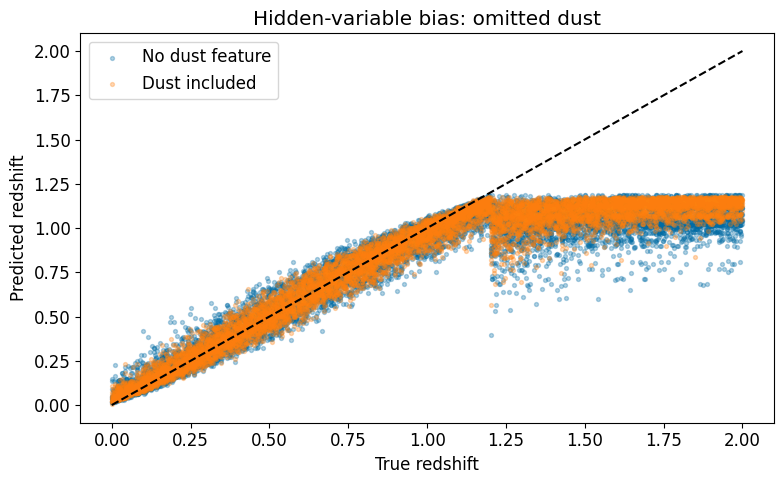

In [36]:
plt.scatter(y_test_dust, pred_rf_without_dust, s=8, alpha=0.3, label="No dust feature")
plt.scatter(y_test_dust, pred_rf_with_dust, s=8, alpha=0.3, label="Dust included")

plt.plot([0,2],[0,2],"k--")

plt.xlabel("True redshift")
plt.ylabel("Predicted redshift")
plt.title("Hidden-variable bias: omitted dust")
plt.legend()
plt.tight_layout()
plt.show()




# 11. Scientific Implications

Errors propagate into:

* cosmological parameters ($\Omega_m$, $\sigma_8$, $H_0$)
* redshift distributions $n(z)$
* survey completeness
* target selection

Thus ML errors become:

> scientific inference biases


# 12. Final Synthesis

## Fundamental limits

* data are biased samples of the universe
* observations are incomplete projections
* models inherit dataset limitations

---

## Central conclusion

> Models do not learn the universe — they learn the observed universe filtered through selection effects.

---

# Core takeaways

* Photometric redshift is a noisy inverse problem
* Training data are biased and incomplete
* RMSE hides regime-dependent failure modes
* Tree models fail via saturation under extrapolation
* Linear models extrapolate but may be misspecified
* Uncertainty is unreliable under distribution shift
* Missing variables dominate identifiability limits

---

# Final message

> Scientific validity requires understanding *where the model is wrong*, not just how often it is right.
